## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, EarlyStopping, get_measures

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(
    data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), 
    batch_size = 64, 
    shuffle = True)

test_loader = data.DataLoader(
    data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), 
    batch_size = 64, 
    shuffle = False)

In [7]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

In [8]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 6,
    outputs = 1,
    rule_reduced = False,
    dtype = x_train.dtype
)

In [9]:
model.show_premises_structure()

                a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
Fuzzy rule 0  0.197601  1.357704  0.323731  0.101866  1.500452  0.284074
Fuzzy rule 1  0.441574  1.339494  0.679219  0.245328  1.886029  0.455952
Fuzzy rule 2  0.248025  1.110971  0.855005  0.985335  1.228377 -0.992770
Fuzzy rule 3  0.275416  1.228533 -0.099599  0.480892  1.345086  0.495795
Fuzzy rule 4  0.731590  1.420692 -0.377717  0.195229  1.128157 -0.166654
Fuzzy rule 5  0.516352  1.385465  0.865213  0.976058  1.499922 -0.997264


In [10]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.01}
early_stopping = EarlyStopping(patience=10, delta=0.01)

trainer = Hybrid_learning_algorithm(
    epochs=200,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.4,
    early_stopping=early_stopping
)

In [11]:
trainer(model, train_loader, verbose=True)

Epoch:   1/200 - loss: 0.054362 - validation loss: 0.057914
Epoch:   2/200 - loss: 0.052432 - validation loss: 0.056076
Epoch:   3/200 - loss: 0.050115 - validation loss: 0.053852
Epoch:   4/200 - loss: 0.050835 - validation loss: 0.053587
Epoch:   5/200 - loss: 0.050818 - validation loss: 0.053516
Epoch:   6/200 - loss: 0.047270 - validation loss: 0.050710
Epoch:   7/200 - loss: 0.045797 - validation loss: 0.048738
Epoch:   8/200 - loss: 0.044934 - validation loss: 0.047637
Epoch:   9/200 - loss: 0.046433 - validation loss: 0.049283
Epoch:  10/200 - loss: 0.046547 - validation loss: 0.049105
Epoch:  11/200 - loss: 0.056745 - validation loss: 0.060827
Epoch:  12/200 - loss: 0.046498 - validation loss: 0.049493
Epoch:  13/200 - loss: 0.043402 - validation loss: 0.046360
Epoch:  14/200 - loss: 0.043220 - validation loss: 0.046080
Epoch:  15/200 - loss: 0.042901 - validation loss: 0.045267
Epoch:  16/200 - loss: 0.045474 - validation loss: 0.047068
Epoch:  17/200 - loss: 0.042262 - valida

In [12]:
model.show_premises_structure()

                a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
Fuzzy rule 0  0.199842  1.356032  0.328164  0.104441  1.495496  0.283438
Fuzzy rule 1  0.442004  1.336071  0.677514  0.244989  1.885534  0.454061
Fuzzy rule 2  0.257633  1.121147  0.844069  0.984627  1.227331 -0.992109
Fuzzy rule 3  0.275061  1.228267 -0.098065  0.482967  1.344362  0.496007
Fuzzy rule 4  0.731131  1.420469 -0.376979  0.194535  1.126187 -0.167634
Fuzzy rule 5  0.513946  1.383767  0.866127  0.975304  1.498899 -0.996416


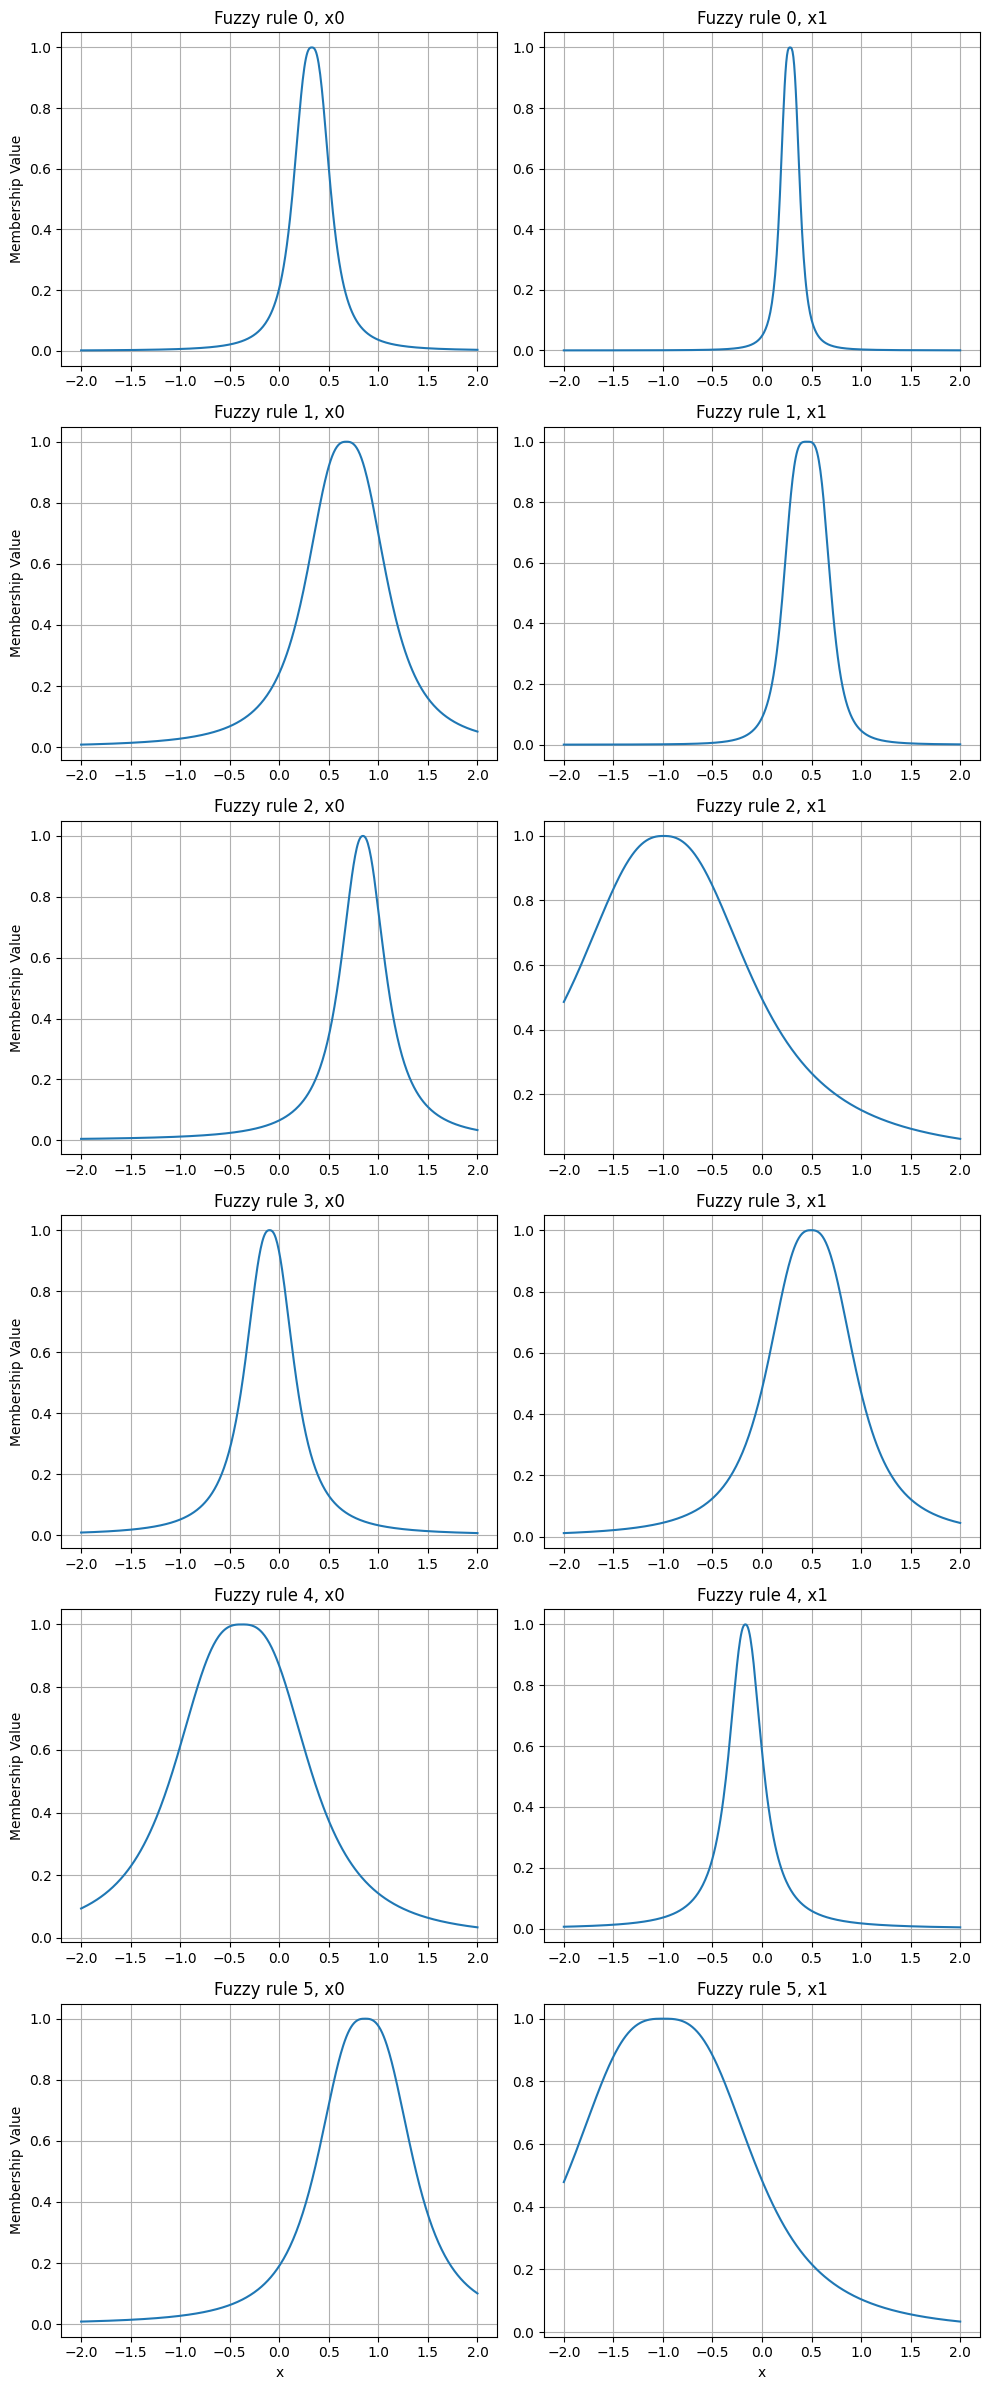

In [13]:
model.plot_premises()

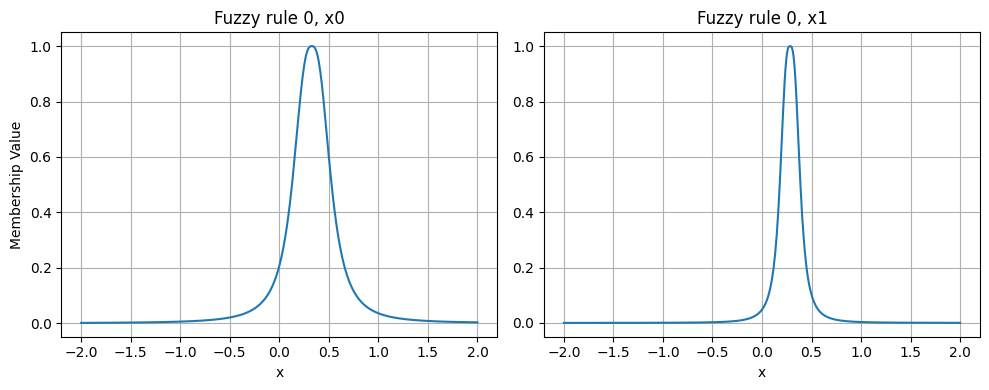

In [14]:
model.plot_premises(fuzzy_rule = 0)

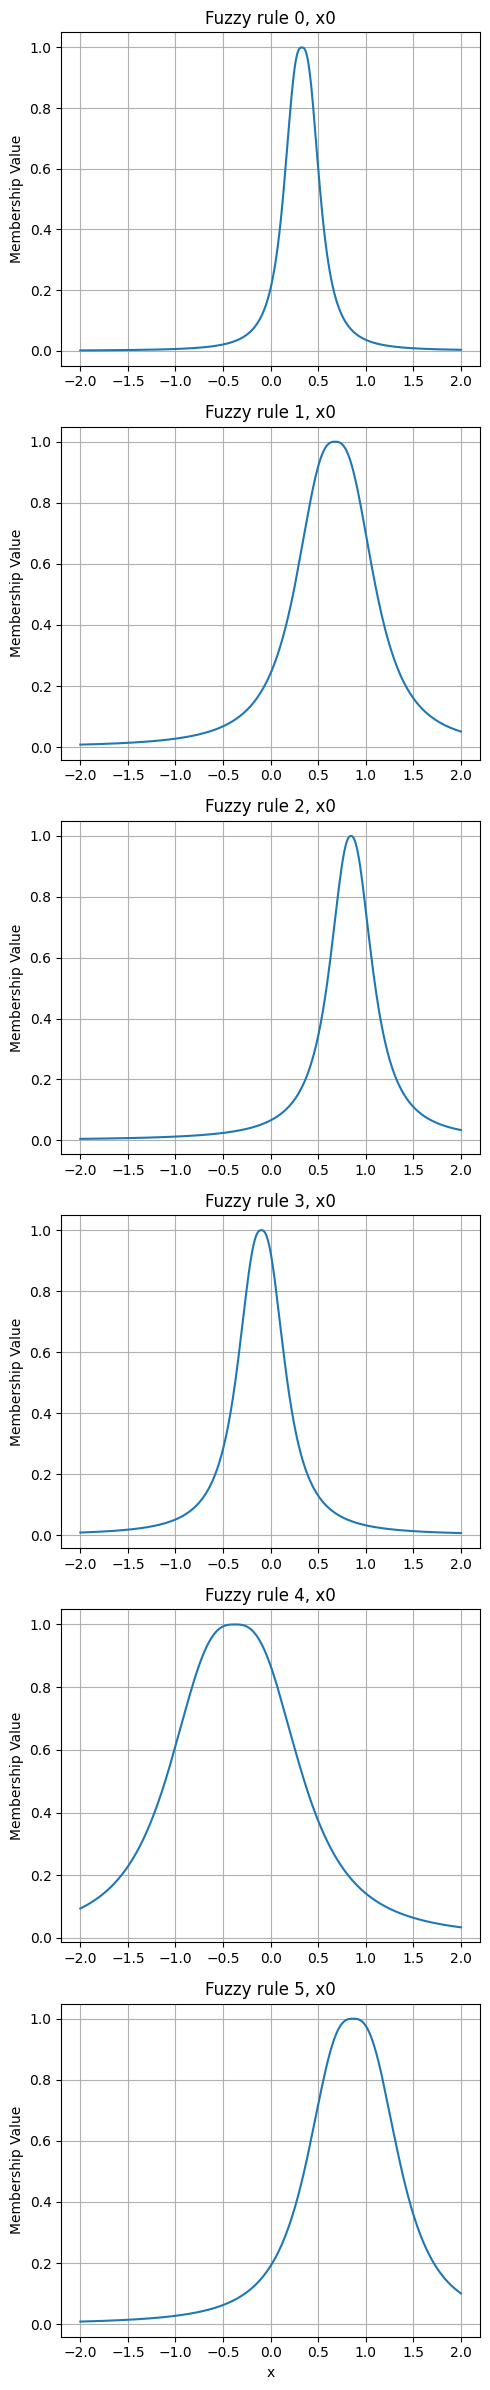

In [15]:
model.plot_premises(input_dim=0)

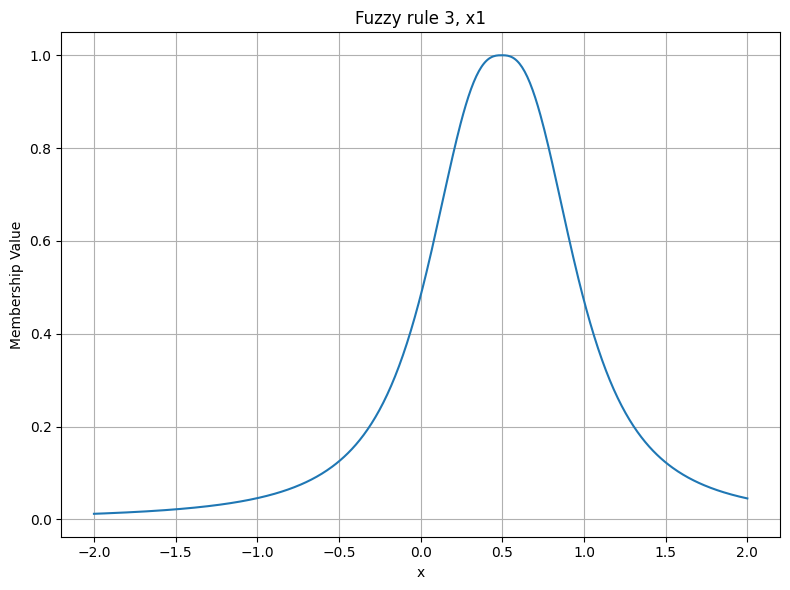

In [16]:
model.plot_premises(fuzzy_rule=3, input_dim=1)

In [17]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 0,0.199842,1.356032,0.328164,0.104441,1.495496,0.283438
Fuzzy rule 1,0.442004,1.336071,0.677514,0.244989,1.885534,0.454061
Fuzzy rule 2,0.257633,1.121147,0.844069,0.984627,1.227331,-0.992109
Fuzzy rule 3,0.275061,1.228267,-0.098065,0.482967,1.344362,0.496007
Fuzzy rule 4,0.731131,1.420469,-0.376979,0.194535,1.126187,-0.167634
Fuzzy rule 5,0.513946,1.383767,0.866127,0.975304,1.498899,-0.996416


In [18]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.036938080853174515
RMSE: 0.19219282206465077
MAE: 0.1419042787051002
R2: 0.9898859761851514
MAPE: 24.35856078447012


In [19]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.04601503996753867
RMSE: 0.21451116513491475
MAE: 0.1645055137785663
R2: 0.9879468174620052
MAPE: 2.6481283712280885


In [21]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 0,0.199842,1.356032,0.328164,0.104441,1.495496,0.283438
Fuzzy rule 1,0.442004,1.336071,0.677514,0.244989,1.885534,0.454061
Fuzzy rule 2,0.257633,1.121147,0.844069,0.984627,1.227331,-0.992109
Fuzzy rule 3,0.275061,1.228267,-0.098065,0.482967,1.344362,0.496007
Fuzzy rule 4,0.731131,1.420469,-0.376979,0.194535,1.126187,-0.167634
Fuzzy rule 5,0.513946,1.383767,0.866127,0.975304,1.498899,-0.996416


In [20]:
model.consequents_structure

[              c0 (x0)        c1 (x1)             c2
 rule 1     636.467801    1122.792523    -660.024817
 rule 2    1423.949695     427.985952    -597.952557
 rule 3   15047.002991  -10373.218863 -199144.739678
 rule 4   -1821.712719    -394.885433     567.171334
 rule 5    -642.900295    1051.821243    6809.563594
 rule 6  -13194.264960  104365.967635  195228.549017
 rule 7    2284.505474    1119.512861   -2912.227102
 rule 8     369.661760    -854.865554    -871.600902
 rule 9   29339.568518   33584.043593  757990.587232
 rule 10  -4719.126236   -4997.976627    9368.144301
 rule 11  -6565.898993   25033.402501   -6042.077998
 rule 12 -18197.183894 -387029.940866 -776974.578412
 rule 13   -691.148468   -1127.314991    1063.114555
 rule 14   -873.076820     342.595834     992.675118
 rule 15 -16159.041832  -45867.076234 -424209.862614
 rule 16   2354.091716    3842.523109   -5764.937551
 rule 17   2419.056487  -13703.730190    6986.569400
 rule 18  11688.764468  255811.184343  431123.